## A simple nonlinear problem
Let us consider the forward response (after Menke, 2012)
    $$f(m)= \sin(\omega m_1 x_i) + m_1 m_2$$
a nonlinear function in both model parameters $m_1$ and $m_2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

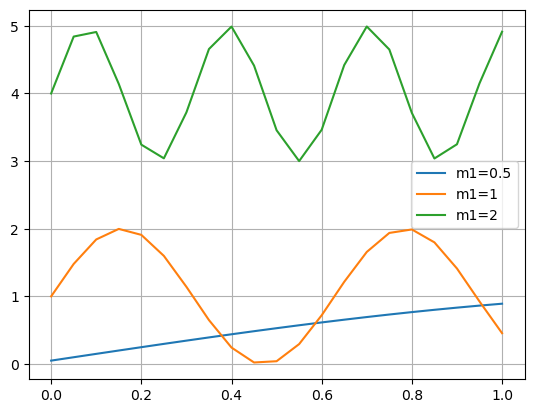

In [2]:
x = np.arange(0, 1.001, 0.05)
omega = 10
forward = lambda m: np.sin(omega * x * m[0]) + m[0] * m[1]
plt.plot(x, forward([0.1, 0.5]), label="m1=0.5")
plt.plot(x, forward([1, 1]), label="m1=1")
plt.plot(x, forward([2, 2]), label="m1=2");
plt.grid()
plt.legend();

Generation of synthetic data with some noise

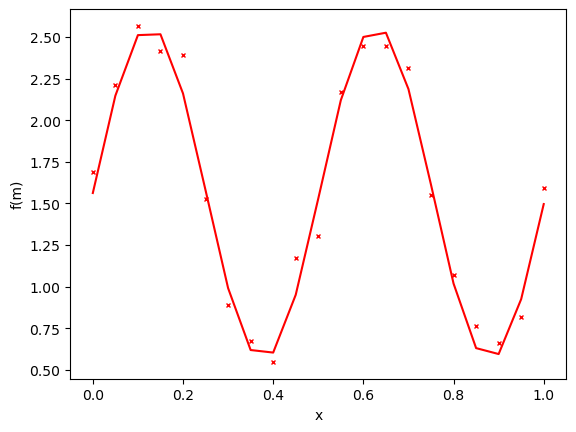

In [3]:
mSynth = [1.25, 1.25]
data = forward(mSynth);
plt.plot(x, data, "r-")
data += np.random.randn(len(data))*0.1;
plt.plot(x, data, "rx");
plt.xlabel("x")
plt.ylabel("f(m)");

### The topology of the objective function
Computation of objective function for a range of model parameters

In [4]:
mrange = np.arange(0, 2.001, 0.01)
Phi = np.zeros([len(mrange), len(mrange)])
for i, m1 in enumerate(mrange):
    for j, m2 in enumerate(mrange):
        Phi[i, j] = np.linalg.norm(data-forward([m1, m2]))

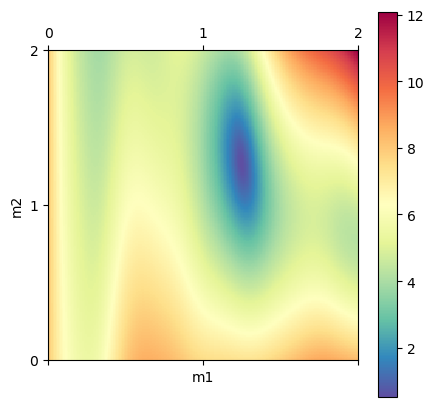

In [10]:
# Show objective function
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.matshow(Phi.T, extent=[mrange[0], mrange[-1], mrange[-1], mrange[0]], cmap="Spectral_r")
ax.set_xlabel("m1")
ax.set_ylabel("m2")
ax.invert_yaxis()
fig.colorbar(im);

In [11]:
# Let's check where the minumum is (Grid Search)
im = np.unravel_index(np.argmin(Phi), Phi.shape)
print([mrange[ii] for ii in im])

[np.float64(1.25), np.float64(1.27)]


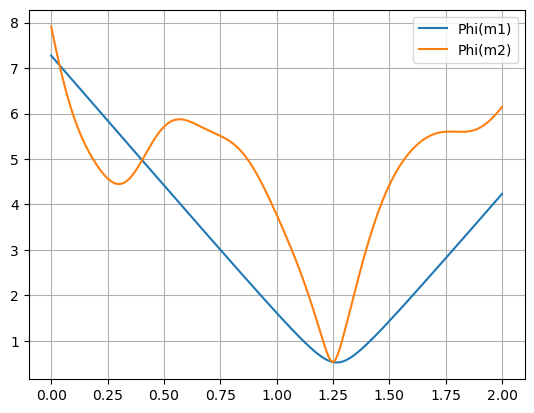

In [12]:
# Let's make two lines through the minimum
plt.plot(mrange, Phi[int(mSynth[0]*100), :], label="Phi(m1)")
plt.plot(mrange, Phi[:, int(mSynth[1]*100)], label="Phi(m2)")
plt.grid()
plt.legend();

The derivatives of the function 
 $$f(m)= \sin(\omega m_1 x_i) + m_1 m_2$$
with respect to $m_1$ and $m_2$ are
$$\frac{\partial f(m)}{\partial m_1} = \omega x_i \cos(\omega m_1 x_i) + m_2$$
$$\frac{\partial f(m)}{\partial m_2} = m_1$$

In [13]:
def sensitivity(model):
    Sens = np.zeros([len(x), 2])
    Sens[:, 0] = omega * x * np.cos(omega*x*model[0]) + model[1]
    Sens[:, 1] = model[0]
    return Sens

def gradient(model, data):
    S = sensitivity(model)
    return -S.T.dot(forward(model)-data) * 2
    # return grad / np.linalg.norm(grad) * 2

def phi(model, data):
    return np.linalg.norm(forward(model)-data)**2

In [16]:
model = [0.4, 0.5]
gr = gradient(model, data)
gr / np.linalg.norm(gr)

array([-0.99247576,  0.12244131])

### The steepest-descent method

In [17]:
def SteepestDescent(model, maxiter=10, starta=1, c=1e-4):
    MOD = [model]
    for i in range(maxiter):
        phi0 = phi(model, data)  # old obj fun
        gr = gradient(model, data)
        gr0 = gr / np.linalg.norm(gr)
        a = starta # Line search
        while not phi(model + a * gr0, data) < phi0 + c * a * gr0.dot(gr):
            a *= 0.5

        model += a*gr0
        MOD.append(np.array(model))
        # print(a, model)

    MOD = np.array(MOD)
    fig, ax = plt.subplots()
    im = ax.matshow(Phi.T, extent=[mrange[0], mrange[-1], mrange[-1], mrange[0]], cmap="Spectral_r")
    ax.set_xlabel("m1")
    ax.set_ylabel("m2")
    ax.invert_yaxis()
    fig.colorbar(im);
    ax.plot(MOD[:, 0], MOD[:, 1], "kx-");
    return ax

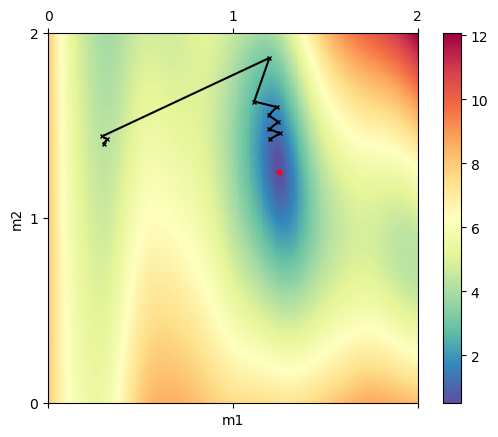

In [36]:
ax = SteepestDescent([0.3, 1.4])#, starta=10, maxiter=10) # .4,.4 .6,1
ax.plot(mSynth[0], mSynth[1], "ro", label="True Model");

### The Gauss-Newton method

In [37]:
def Hessian(model):
    S = sensitivity(model)
    return S.T.dot(S) * 2

def linesearch(data, modelN, deltaModelN, fak=100, taumax=1):
    lsphi = np.zeros(fak*taumax)
    for i in range(1, len(lsphi)+1):
        modelN1 = modelN + deltaModelN * (i/fak)
        lsphi[i] = np.linalg.norm(data-forward(modelN1))

    return (np.argmin(lsphi)+1) / fak

def GaussNewton(model, maxiter=10, starta=1, c=1e-4):
    MOD = [model]
    for i in range(maxiter):
        a = starta
        phi0 = phi(model, data)
        gr = gradient(model, data)
        # gr0 = gr / np.linalg.norm(gr)
        H = Hessian(model)
        dmodel = np.linalg.solve(H, gr)
        # a = linesearch(data, model, dmodel)
        a = starta # Line search
        # while not phi(model + a * dmodel, data) < phi0:
        #     a *= 0.3

        model += a*dmodel
        MOD.append(np.array(model))
        # print(a, model)

    MOD = np.array(MOD)
    fig, ax = plt.subplots()
    im = ax.matshow(Phi.T, extent=[mrange[0], mrange[-1], mrange[-1], mrange[0]], cmap="Spectral_r")
    ax.set_xlabel("m1")
    ax.set_ylabel("m2")
    ax.invert_yaxis()
    fig.colorbar(im);
    ax.plot(MOD[:, 0], MOD[:, 1], "kx-");
    return ax

In [ ]:
model = [0.6, 0.4]
print(np.linalg.lstsq(sensitivity(model), data - forward(model))[0])
print(np.linalg.solve(Hessian(model), gradient(model, data)))

[-0.02542902  2.20895914]
[-0.02542902  2.20895914]


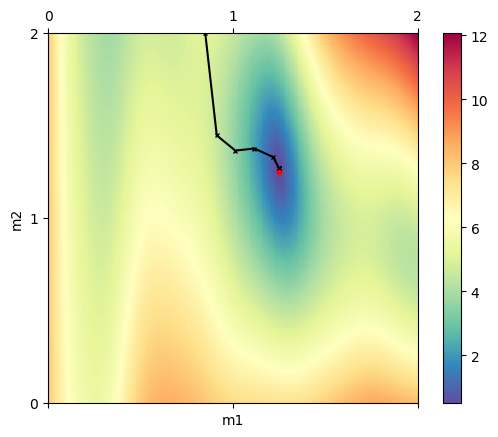

In [52]:
ax = GaussNewton([0.85, 2])
ax.plot(mSynth[0], mSynth[1], "ro", label="True Model");

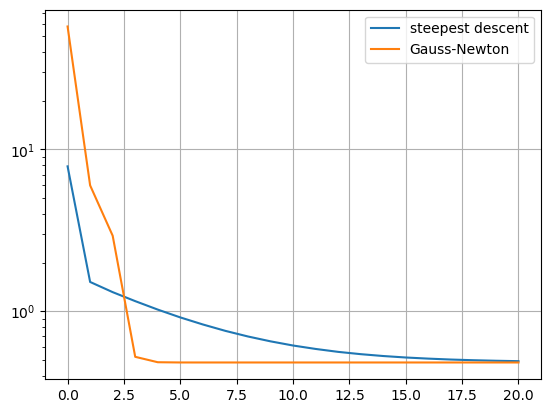

In [ ]:
semilogy(fitSD, label="steepest descent");
semilogy(fitGN, label="Gauss-Newton");
grid()
legend();

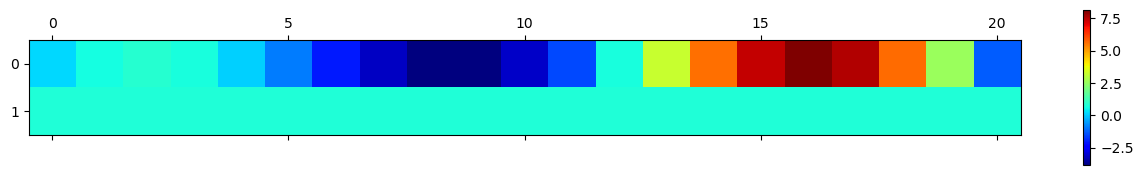

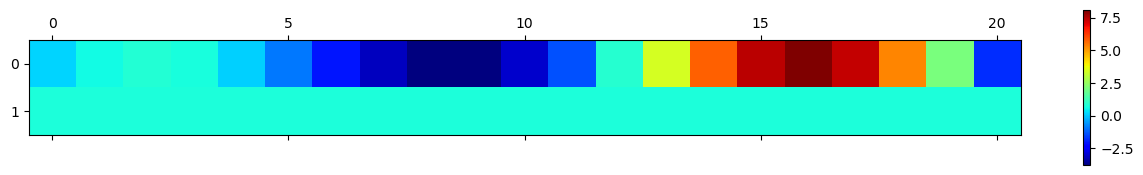

PyObject <matplotlib.colorbar.Colorbar object at 0x0000000058DE9988>

In [ ]:
model = [0.8, 0.2]
fm = forward(model)
S = sensitivity(model)
matshow(transpose(S))
colorbar()
S1 = hcat(forward(model+[0.01, 0]).-fm, forward(model+[0, 0.01]).-fm) / 0.01
matshow(transpose(S1))
colorbar()